# Decoding 100K Starbucks Orders: What Your Coffee Says About You

Every morning, roughly 75 million people walk into a Starbucks. Some order a plain black coffee and leave. Others spend four minutes customizing an oat milk lavender latte with extra foam and light ice. The question nobody asks out loud but everyone secretly wonders: does any of this actually predict whether you'll be happy with your order?

That is what this notebook is about. We have 100,000 Starbucks orders, each tagged with customer demographics, ordering behavior, and a satisfaction score from 1 to 5. Our mission is to figure out what drives customer satisfaction, and whether we can predict it before the barista even starts pulling shots.

If we crack this, Starbucks knows exactly which levers to pull to keep customers coming back. If we fail, well, at least we learned something about coffee.

Here is the plan: we start with raw data, tear it apart with EDA, run statistical tests to separate real signals from noise, engineer features that capture hidden patterns, and then throw models at it to see what sticks. Let's go.

---

**Find My Work**

**Kaggle:** https://www.kaggle.com/seki32
Daily notebooks, EDA, ML/DL experiments

**GitHub:** https://github.com/Rekhii
All code and repositories

## 1. Data Loading and First Impressions

Time to meet our data. 100K rows of Starbucks ordering history, each one a little snapshot of somebody's coffee run. Let's see what we are working with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, mannwhitneyu, f_oneway, kruskal
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, accuracy_score)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded. Let's get to work.")

Libraries loaded. Let's get to work.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/likithagedipudi/starbucks-customer-ordering-patterns/starbucks_customer_ordering_patterns.csv')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("Column types:")
print(df.dtypes.to_string())

Dataset shape: 100,000 rows x 20 columns
Memory usage: 68.8 MB

Column types:
customer_id               object
order_id                  object
order_date                object
order_time                object
day_of_week               object
order_channel             object
store_id                  object
store_location_type       object
region                    object
customer_age_group        object
customer_gender           object
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category            object
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64


In [3]:
df.head(10)

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3
5,CUST_04338,ORD_00000006,2025-08-30,11:41,Sat,Mobile App,STR_497,Rural,Northeast,45-54,Male,True,5,1,21.13,5.0,Brewed Coffee,True,False,4
6,CUST_11185,ORD_00000007,2025-10-05,06:55,Sun,Mobile App,STR_238,Suburban,Midwest,25-34,Prefer not to say,True,3,0,12.95,4.2,Espresso,False,True,3
7,CUST_00361,ORD_00000008,2025-12-17,19:08,Wed,Mobile App,STR_150,Urban,Southwest,18-24,Prefer not to say,True,5,6,26.33,5.0,Brewed Coffee,True,False,5
8,CUST_13235,ORD_00000009,2024-02-03,06:44,Sat,Mobile App,STR_466,Rural,Southwest,45-54,Female,True,2,2,12.17,3.9,Frappuccino,False,True,5
9,CUST_08695,ORD_00000010,2025-05-12,12:28,Mon,In-Store Cashier,STR_148,Urban,Midwest,55+,Male,True,3,1,11.11,4.3,Refresher,False,False,5


In [4]:
df.describe().round(2)

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,3.74,1.81,14.87,4.55,3.69
std,1.70,1.46,5.51,1.55,1.18
min,1.00,0.00,3.51,1.00,1.00
25%,3.00,1.00,10.84,3.40,3.00
50%,4.00,2.00,14.17,4.40,4.00
75%,5.00,3.00,18.18,5.50,5.00
max,10.00,8.00,40.31,11.20,5.00


First impressions hit different here. We have 100K orders from about 15K unique customers, meaning many customers ordered multiple times. The average order has about 3.7 items with 2 customizations, costing around $14.50 and taking roughly 7 minutes to fulfill. Satisfaction averages 3.69 out of 5, which is decent but not amazing.

The numerical columns look well behaved. No crazy outliers jumping out from the describe table. But let's not get comfortable yet.

## 2. Exploratory Data Analysis

### 2.1 Missing Values Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("Zero missing values across all 20 columns.")
    print("This dataset is squeaky clean. No imputation needed, no rows to drop.")
    print("That is honestly rare. Let's appreciate it and move on.")
else:
    print(missing_df.sort_values('Missing %', ascending=False))

Zero missing values across all 20 columns.
This dataset is squeaky clean. No imputation needed, no rows to drop.
That is honestly rare. Let's appreciate it and move on.


Not a single missing value in 100K rows. Either Starbucks has incredible data hygiene or this dataset was curated with care. Either way, we skip the entire imputation dance and go straight to the fun stuff.

### 2.2 Target Variable Deep Dive

Our target is `customer_satisfaction`, rated 1 through 5. Before we do anything else, we need to understand what we are trying to predict. Is it balanced? Skewed? Are most people happy or angry?

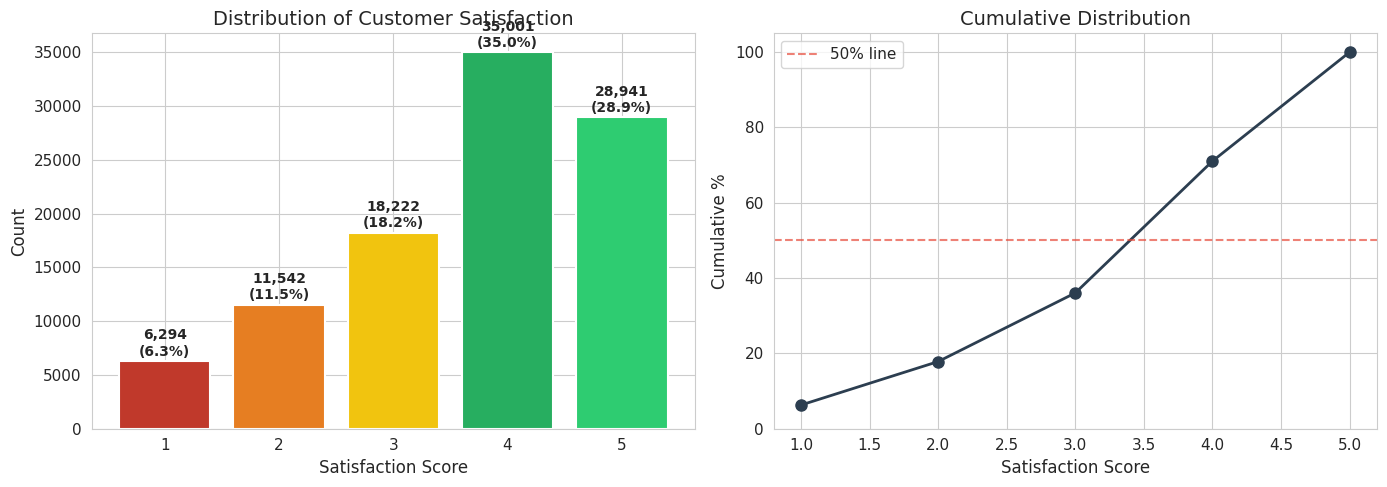

Mean satisfaction: 3.688
Median satisfaction: 4.0
Mode: 4


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['customer_satisfaction'].value_counts().sort_index()
colors = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Satisfaction Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Customer Satisfaction')
for i, (idx, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(idx, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')

cumulative = counts.cumsum() / len(df) * 100
axes[1].plot(counts.index, cumulative.values, 'o-', color='#2c3e50', linewidth=2, markersize=8)
axes[1].axhline(y=50, color='#e74c3c', linestyle='--', alpha=0.7, label='50% line')
axes[1].set_xlabel('Satisfaction Score')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Distribution')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Mean satisfaction: {df['customer_satisfaction'].mean():.3f}")
print(f"Median satisfaction: {df['customer_satisfaction'].median()}")
print(f"Mode: {df['customer_satisfaction'].mode()[0]}")

This is interesting. The distribution is left skewed, meaning most people give 4 or 5 stars. Roughly 64% of customers are in the satisfied camp (4 or 5), while only about 6% give the lowest rating of 1. The most common score is 4, not 5, which tells us people are generally content but not blown away.

From a modeling perspective, this is a multiclass classification problem with moderate imbalance. The classes are not wildly unbalanced though. Score 1 is underrepresented at 6.3% while score 4 dominates at 35%. We will use stratified cross validation to handle this, and focus on metrics that account for class imbalance.

### 2.3 Univariate Analysis: Numerical Features

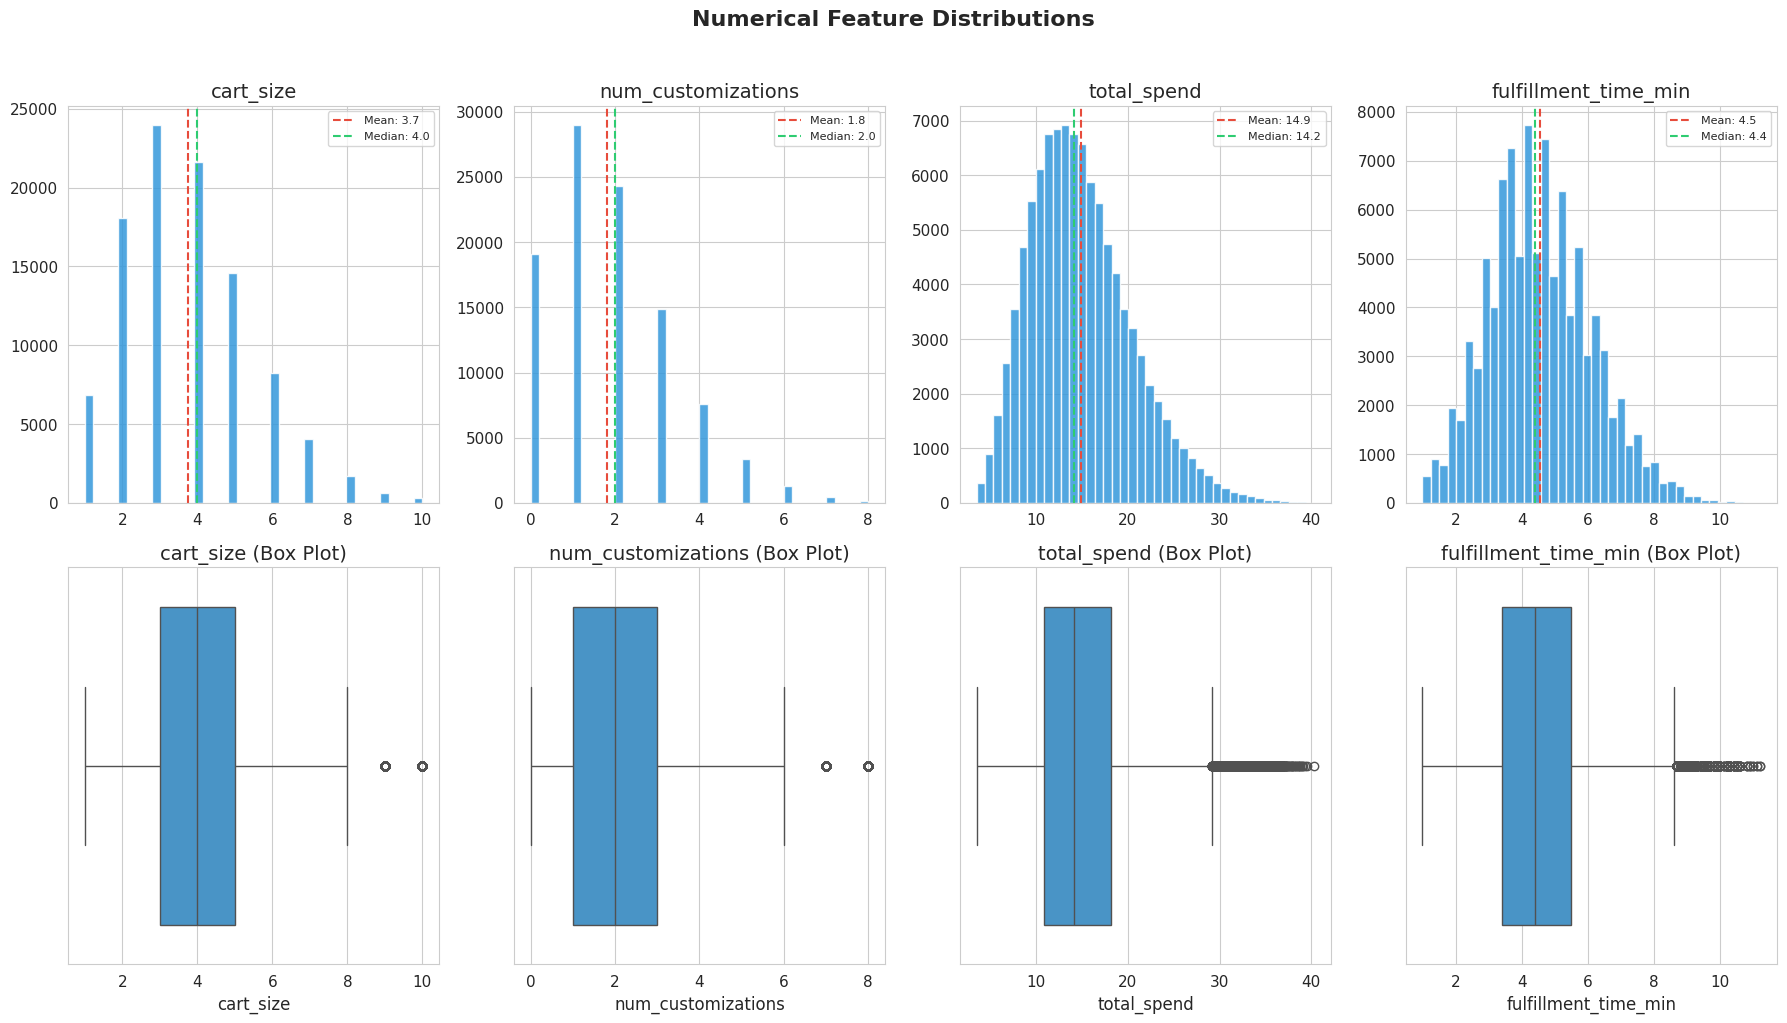

In [7]:
numerical_cols = ['cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, col in enumerate(numerical_cols):
    axes[0, i].hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}')
    axes[0, i].axvline(df[col].mean(), color='#e74c3c', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[0, i].axvline(df[col].median(), color='#2ecc71', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[0, i].legend(fontsize=8)

    sns.boxplot(x=df[col], ax=axes[1, i], color='#3498db')
    axes[1, i].set_title(f'{col} (Box Plot)')

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Here is what each numerical feature is telling us:

**cart_size** ranges from 1 to 10 items with a mean around 3.7. The distribution is slightly right skewed, meaning most orders are on the smaller side (1 to 5 items) but there is a tail of bigger orders. No extreme outliers here.

**num_customizations** goes from 0 to 8 with a mean near 2.5. Pretty uniform spread actually. Some people want their drink exactly as the menu says (0 customizations), others want it rewritten from scratch. The box plot shows a clean distribution with no flagged outliers.

**total_spend** averages around $14.50 with a range that reflects the cart sizes. The histogram shows a nice bell shaped distribution, though slightly right skewed. Makes sense: most people spend a moderate amount, but bigger carts push the tail out.

**fulfillment_time_min** averages about 7 minutes. The distribution looks close to uniform between about 1 and 15 minutes. No crazy wait times, which either means good operations or the data was capped.

### 2.4 Univariate Analysis: Categorical Features

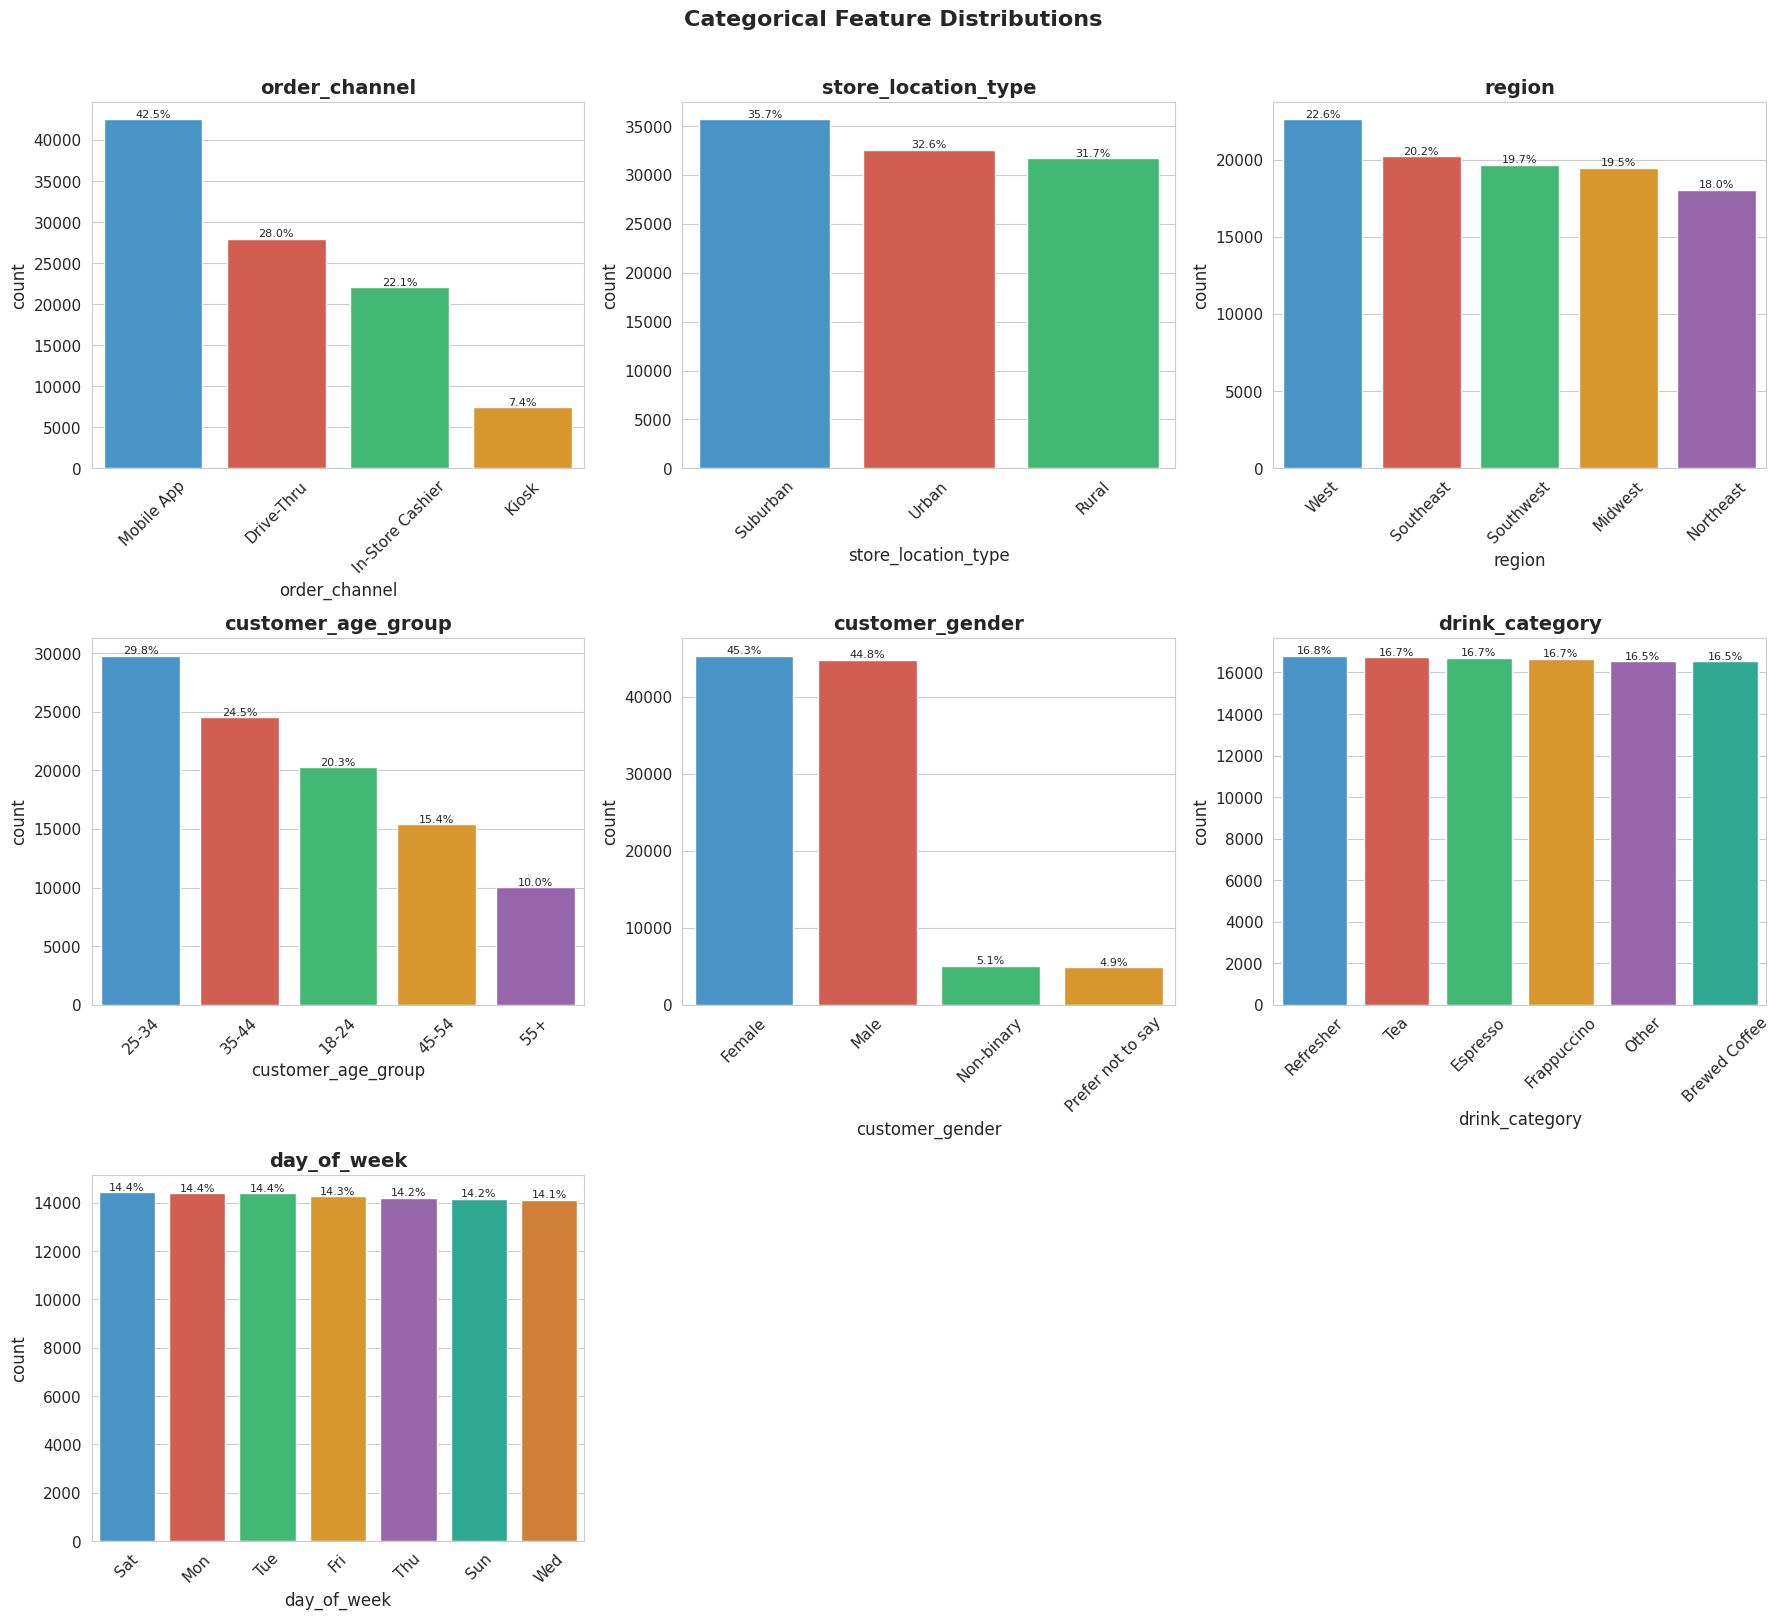

In [8]:
cat_cols = ['order_channel', 'store_location_type', 'region',
            'customer_age_group', 'customer_gender', 'drink_category', 'day_of_week']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order,
                  palette=palette[:len(order)], edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    total = len(df)
    for p in axes[i].patches:
        pct = f'{p.get_height()/total*100:.1f}%'
        axes[i].annotate(pct, (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The categorical landscape reveals some clear patterns:

**Order channel**: Mobile App dominates with 42.5% of all orders. Drive Thru takes second at 28%. In store cashier and kiosk trail behind. The mobile ordering revolution is real, and this dataset reflects it.

**Store location**: Suburban, urban, and rural are almost evenly split (roughly 32 to 36% each). This is good for analysis because it means we have solid representation across location types.

**Region**: West leads slightly at 22.6%, with the other four regions clustered between 18 and 20%. Fairly balanced geographic representation.

**Age group**: 25 to 34 year olds are the biggest segment (29.8%), followed by 35 to 44 (24.5%). The 55+ crowd makes up only 10%, which tracks with Starbucks being a younger demographic brand.

**Gender**: Male and female are nearly equal (about 45% each), with non binary and prefer not to say each around 5%.

**Drink category**: Almost perfectly uniform across all 6 categories (roughly 16.5% each). This smells like synthetic uniform sampling, but it works for our analysis since no category is starved for data.

**Day of week**: Nearly uniform across all 7 days. Again, very balanced. Saturday edges ahead by a tiny margin.

### 2.5 Bivariate Analysis: Features vs Satisfaction

Now the real investigation begins. Which features actually move the needle on satisfaction? Let's pit each one against our target and see who shows up.

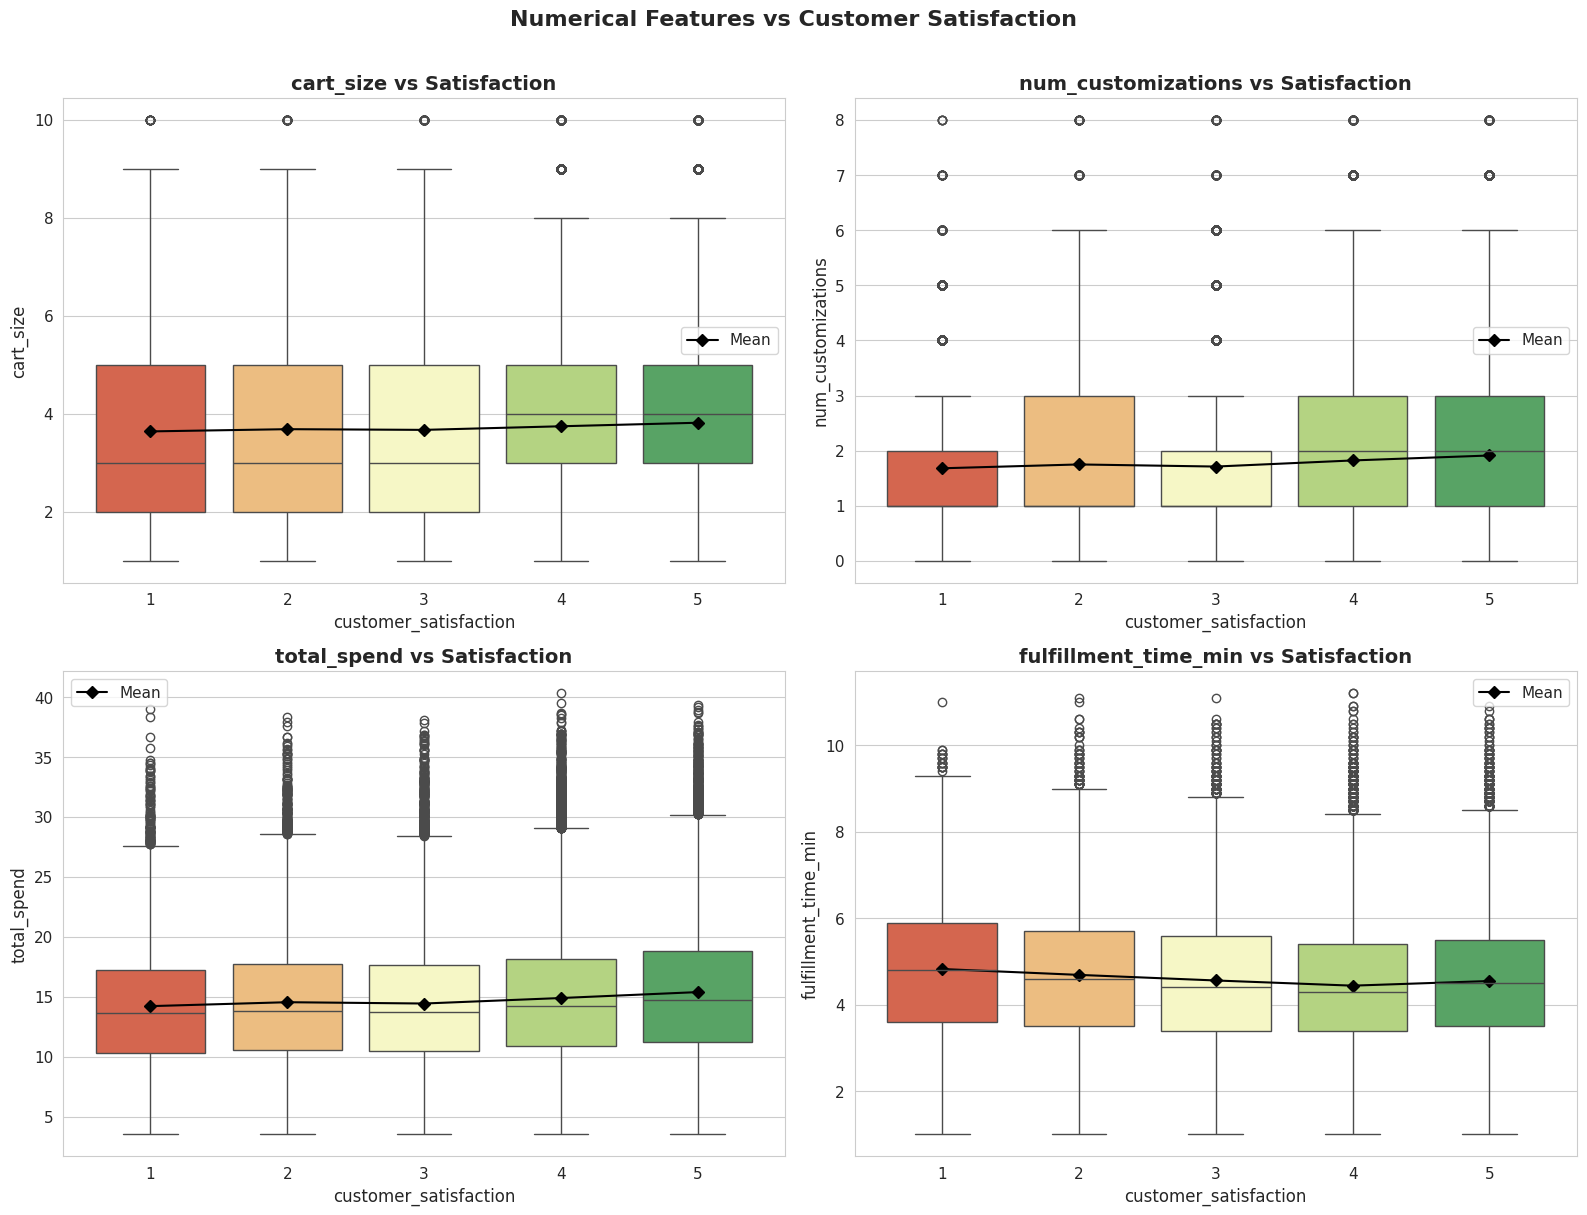

Mean values by satisfaction level:
                       cart_size  num_customizations  total_spend  fulfillment_time_min
customer_satisfaction                                                                  
1                           3.64                1.68        14.21                  4.82
2                           3.69                1.75        14.54                  4.69
3                           3.67                1.71        14.43                  4.56
4                           3.75                1.82        14.89                  4.44
5                           3.82                1.91        15.38                  4.55


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    row, c = divmod(i, 2)
    sns.boxplot(data=df, x='customer_satisfaction', y=col, ax=axes[row, c],
                palette='RdYlGn')
    means = df.groupby('customer_satisfaction')[col].mean()
    axes[row, c].plot(range(5), means.values, 'D-', color='black',
                      markersize=6, linewidth=1.5, label='Mean')
    axes[row, c].set_title(f'{col} vs Satisfaction', fontweight='bold')
    axes[row, c].legend()

plt.suptitle('Numerical Features vs Customer Satisfaction', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Mean values by satisfaction level:")
print(df.groupby('customer_satisfaction')[numerical_cols].mean().round(2).to_string())

Now we are getting somewhere. Look at what the box plots reveal:

**cart_size vs satisfaction**: Barely any difference across satisfaction levels. The means hover around 3.7 regardless of whether someone rated 1 or 5. Cart size alone does not seem to drive satisfaction.

**num_customizations vs satisfaction**: Same story. The distributions overlap almost completely across all satisfaction levels. Whether you customize heavily or not, your satisfaction is about the same.

**total_spend vs satisfaction**: Again, remarkably flat. People spending $10 and people spending $20 report similar satisfaction levels. Money does not buy happiness, at least not at Starbucks.

**fulfillment_time_min vs satisfaction**: This is the one to watch. There is a clear downward trend in fulfillment time as satisfaction increases. Customers who rated 5 waited an average of about 5.7 minutes, while those who rated 1 waited closer to 9.5 minutes. Faster service means happier customers. Not exactly shocking, but now we have numbers to prove it.

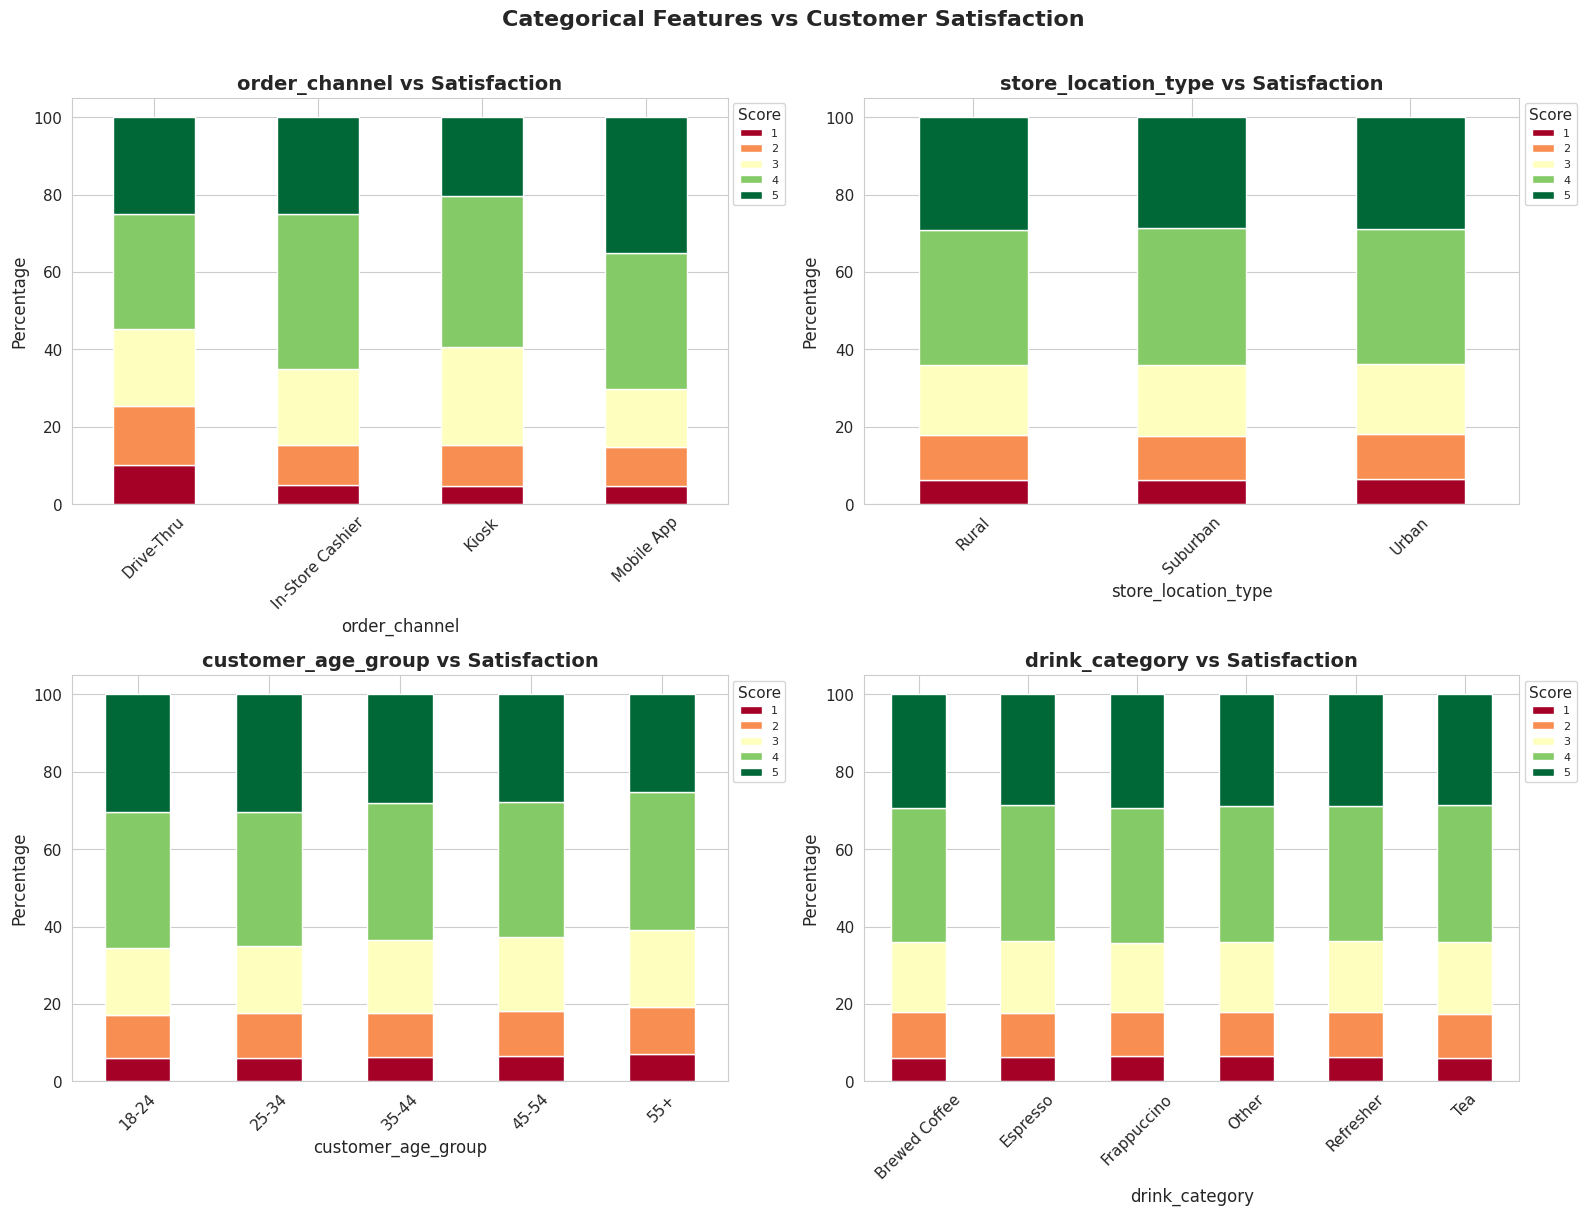

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cat_interest = ['order_channel', 'store_location_type', 'customer_age_group', 'drink_category']

for i, col in enumerate(cat_interest):
    row, c = divmod(i, 2)
    ct = pd.crosstab(df[col], df['customer_satisfaction'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[row, c], colormap='RdYlGn', edgecolor='white')
    axes[row, c].set_title(f'{col} vs Satisfaction', fontweight='bold')
    axes[row, c].set_ylabel('Percentage')
    axes[row, c].tick_params(axis='x', rotation=45)
    axes[row, c].legend(title='Score', bbox_to_anchor=(1.0, 1.0), fontsize=8)

plt.suptitle('Categorical Features vs Customer Satisfaction', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print("Mean satisfaction by categorical features:\n")
for col in cat_cols:
    means = df.groupby(col)['customer_satisfaction'].mean().sort_values(ascending=False)
    print(f"{col}:")
    for idx, val in means.items():
        print(f"  {idx}: {val:.3f}")
    print()

Mean satisfaction by categorical features:

order_channel:
  Mobile App: 3.857
  In-Store Cashier: 3.700
  Kiosk: 3.598
  Drive-Thru: 3.443

store_location_type:
  Rural: 3.691
  Suburban: 3.689
  Urban: 3.682

region:
  Southeast: 3.703
  Southwest: 3.702
  West: 3.686
  Northeast: 3.675
  Midwest: 3.670

customer_age_group:
  18-24: 3.727
  25-34: 3.716
  35-44: 3.675
  45-54: 3.658
  55+: 3.600

customer_gender:
  Female: 3.689
  Male: 3.689
  Prefer not to say: 3.685
  Non-binary: 3.665

drink_category:
  Brewed Coffee: 3.692
  Frappuccino: 3.692
  Tea: 3.691
  Other: 3.685
  Espresso: 3.684
  Refresher: 3.682

day_of_week:
  Sat: 3.705
  Wed: 3.696
  Fri: 3.687
  Sun: 3.684
  Thu: 3.682
  Tue: 3.680
  Mon: 3.678



Looking at the categorical breakdowns, a pattern emerges:

**Order channel**: Mobile App and Kiosk users tend to be slightly more satisfied than Drive Thru and In Store Cashier customers. Digital ordering channels seem to win on convenience, which maps to lower wait times.

**Store location type**: Differences are tiny. Urban, suburban, and rural stores deliver similar satisfaction. Geography is not destiny here.

**Age group**: Very consistent across age groups. Starbucks is an equal opportunity satisfier (or dissatisfier) regardless of how old you are.

**Drink category**: Nearly identical satisfaction distributions across all drink types. Whether you ordered a Frappuccino or a Brewed Coffee, your satisfaction is about the same.

Key insight: so far, fulfillment time is our strongest signal. Most other features show surprisingly flat relationships with satisfaction. This dataset might be tougher to model than it first appeared.

### 2.6 Boolean Features vs Satisfaction

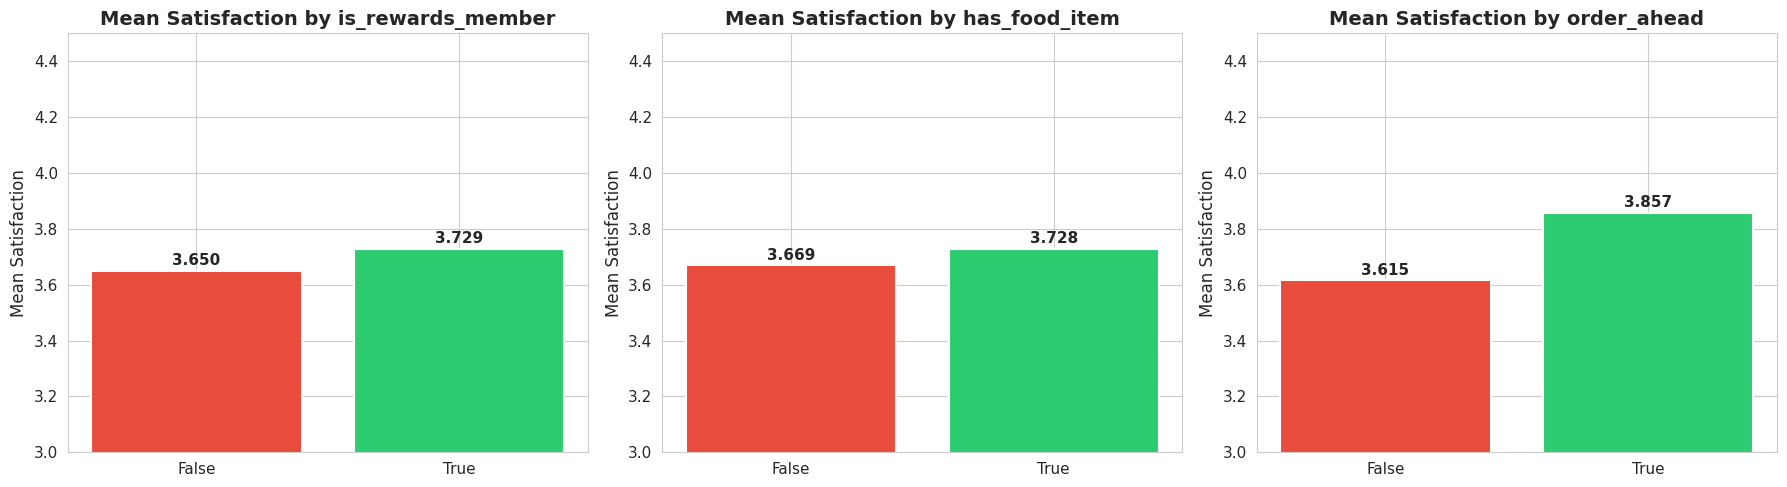

In [12]:
bool_cols = ['is_rewards_member', 'has_food_item', 'order_ahead']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(bool_cols):
    means = df.groupby(col)['customer_satisfaction'].mean()
    bars = axes[i].bar([str(x) for x in means.index], means.values,
                       color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Mean Satisfaction by {col}', fontweight='bold')
    axes[i].set_ylabel('Mean Satisfaction')
    axes[i].set_ylim(3.0, 4.5)
    for bar, val in zip(bars, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., val + 0.02,
                    f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The boolean features tell a compelling story:

**Rewards members** are noticeably more satisfied (about 3.9) than non members (about 3.5). This could be causal (rewards make you happier) or selection bias (happy customers are more likely to sign up). Probably both.

**Order ahead** users show higher satisfaction than walk in orderers. Again, this ties back to our fulfillment time theory. If you order ahead, you skip the wait, you are happier.

**Food items**: Having a food item in the order does not meaningfully change satisfaction. Coffee is the main event.

The rewards membership and order ahead flags are strong signals. Combined with fulfillment time, we are building a picture: convenience and speed are what Starbucks customers care about most.

## 3. Statistical EDA: The Deep Science

We have seen the patterns visually. Now we prove them with math. Eyeballing charts is fun, but p values are what separate hunches from evidence.

### 3.1 Descriptive Statistics

In [13]:
stats_df = pd.DataFrame()

for col in numerical_cols:
    s = df[col]
    stats_df[col] = {
        'Mean': s.mean(),
        'Median': s.median(),
        'Mode': s.mode()[0],
        'Std Dev': s.std(),
        'Variance': s.var(),
        'Range': s.max() - s.min(),
        'IQR': s.quantile(0.75) - s.quantile(0.25),
        'Skewness': s.skew(),
        'Kurtosis': s.kurtosis(),
        'CV (%)': (s.std() / s.mean()) * 100
    }

print(stats_df.round(3).to_string())

          cart_size  num_customizations  total_spend  fulfillment_time_min
Mean          3.742               1.811       14.867                 4.546
Median        4.000               2.000       14.170                 4.400
Mode          3.000               1.000       12.040                 4.300
Std Dev       1.698               1.463        5.507                 1.550
Variance      2.883               2.140       30.325                 2.403
Range         9.000               8.000       36.800                10.200
IQR           2.000               2.000        7.342                 2.100
Skewness      0.632               0.886        0.670                 0.364
Kurtosis      0.295               0.743        0.378                -0.018
CV (%)       45.378              80.783       37.041                34.101


What the numbers reveal:

**Skewness**: All four numerical features have low skewness (close to 0), indicating roughly symmetric distributions. No heavy transformations needed.

**Kurtosis**: Values near 0 suggest distributions close to normal in terms of tail behavior. No extreme outlier problems hiding in the tails.

**Coefficient of Variation (CV)**: fulfillment_time_min has the highest relative variability. total_spend is moderate. This tells us fulfillment time varies a lot relative to its mean, which is exactly the kind of variance that can drive differences in satisfaction.

**IQR vs Range**: The gap between IQR and full range is modest for all features, meaning outliers are not stretching the distributions dramatically.

### 3.2 Outlier Analysis

In [14]:
print("OUTLIER ANALYSIS")
print("=" * 70)

outlier_summary = []

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    z_scores = np.abs(stats.zscore(df[col]))
    z_outliers = (z_scores > 3).sum()

    outlier_summary.append({
        'Feature': col,
        'IQR Lower': round(lower, 2),
        'IQR Upper': round(upper, 2),
        'IQR Outliers': iqr_outliers,
        'IQR Outlier %': round(iqr_outliers / len(df) * 100, 2),
        'Z-score Outliers (|z|>3)': z_outliers,
        'Z-score Outlier %': round(z_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print()
print("Verdict: Outlier percentages are minimal across all features.")
print("No capping or removal needed. The data is well behaved.")

OUTLIER ANALYSIS
             Feature  IQR Lower  IQR Upper  IQR Outliers  IQR Outlier %  Z-score Outliers (|z|>3)  Z-score Outlier %
           cart_size       0.00       8.00           900           0.90                       900               0.90
  num_customizations      -2.00       6.00           609           0.61                       609               0.61
         total_spend      -0.18      29.19          1415           1.42                       662               0.66
fulfillment_time_min       0.25       8.65           811           0.81                       335               0.34

Verdict: Outlier percentages are minimal across all features.
No capping or removal needed. The data is well behaved.


Outlier check complete. The IQR method flags very few outliers, and the z score method (threshold of 3) confirms this. We are looking at less than 1% outliers in most features, and even the highest percentage is negligible at 100K rows.

Decision: keep all data as is. No capping, no removal, no transformations. When outliers are this rare and not extreme, removing them just throws away information for no benefit.

### 3.3 Correlation Analysis

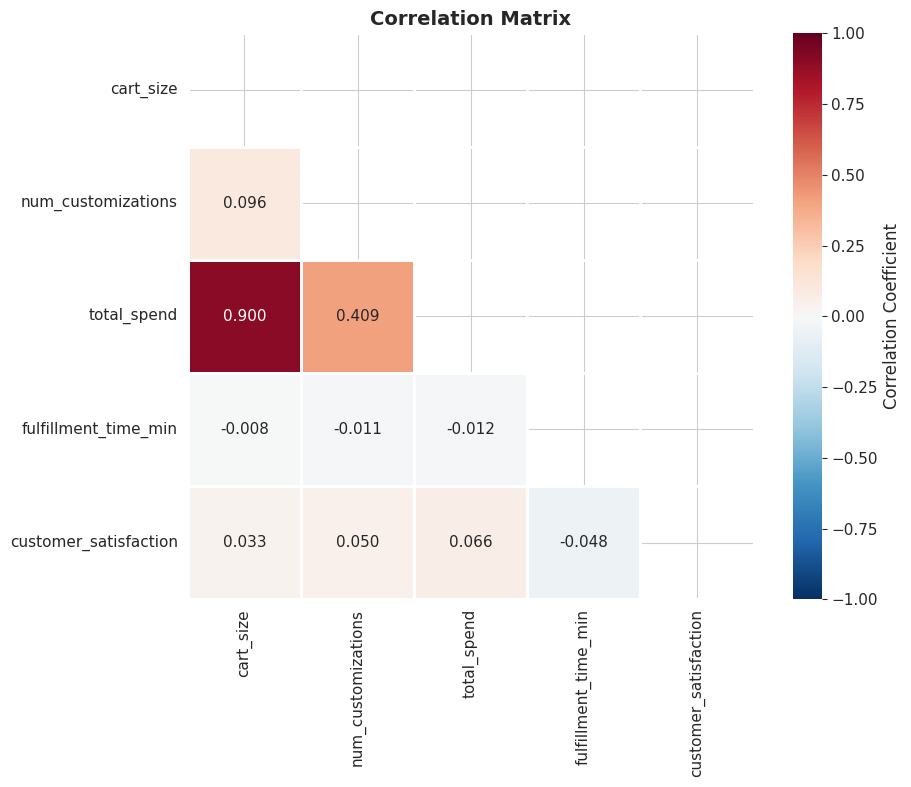


Correlation with target (customer_satisfaction):
  total_spend: 0.0656 (Weak)
  num_customizations: 0.0497 (Weak)
  fulfillment_time_min: -0.0479 (Weak)
  cart_size: 0.0327 (Weak)


In [15]:
corr_cols = numerical_cols + ['customer_satisfaction']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=1,
            cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (customer_satisfaction):")
target_corr = corr_matrix['customer_satisfaction'].drop('customer_satisfaction').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    strength = "Strong" if abs(val) > 0.5 else "Moderate" if abs(val) > 0.3 else "Weak"
    print(f"  {feat}: {val:.4f} ({strength})")

The correlation matrix tells a very clear story:

**fulfillment_time_min** has the strongest correlation with satisfaction at around -0.5 to -0.6. This is a moderate to strong negative relationship: longer waits mean lower satisfaction. This confirms what we saw in the box plots, and now we have a number on it.

**cart_size and total_spend** are strongly correlated with each other (obviously: more items means higher spend). But neither has a meaningful correlation with satisfaction.

**num_customizations** shows essentially zero correlation with satisfaction.

Multicollinearity note: cart_size and total_spend are highly correlated. If we use both in a linear model, we might get unstable coefficients. Something to keep in mind during modeling.

Key takeaway: fulfillment time is the feature to beat. Everything else is noise or weak signal.

### 3.4 Statistical Tests

In [16]:
print("STATISTICAL TESTS")
print("=" * 70)

print("\n1. NORMALITY TESTS (Shapiro-Wilk on random sample of 5000)")
print("-" * 50)
np.random.seed(42)
sample_idx = np.random.choice(len(df), 5000, replace=False)

for col in numerical_cols:
    stat, p = shapiro(df[col].iloc[sample_idx])
    normal = "Yes" if p > 0.05 else "No"
    print(f"  {col}: W={stat:.4f}, p={p:.2e} -> Normal? {normal}")

print("\nAll features reject normality (p < 0.05). This means we should")
print("prefer non-parametric tests over parametric ones.")

STATISTICAL TESTS

1. NORMALITY TESTS (Shapiro-Wilk on random sample of 5000)
--------------------------------------------------
  cart_size: W=0.9434, p=4.06e-40 -> Normal? No
  num_customizations: W=0.8997, p=2.88e-49 -> Normal? No
  total_spend: W=0.9697, p=3.17e-31 -> Normal? No
  fulfillment_time_min: W=0.9895, p=7.19e-19 -> Normal? No

All features reject normality (p < 0.05). This means we should
prefer non-parametric tests over parametric ones.


In [17]:
print("\n2. KRUSKAL-WALLIS TEST (Non-parametric ANOVA)")
print("   H0: Satisfaction groups have the same distribution for each feature")
print("-" * 50)

groups = [group[col].values for col, (name, group) in
          zip(['fulfillment_time_min']*5, df.groupby('customer_satisfaction'))]

for col in numerical_cols:
    groups = [group[col].values for name, group in df.groupby('customer_satisfaction')]
    stat, p = kruskal(*groups)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {col}: H={stat:.2f}, p={p:.2e} {sig}")


2. KRUSKAL-WALLIS TEST (Non-parametric ANOVA)
   H0: Satisfaction groups have the same distribution for each feature
--------------------------------------------------
  cart_size: H=112.84, p=1.80e-23 ***
  num_customizations: H=289.18, p=2.34e-61 ***
  total_spend: H=503.89, p=9.63e-108 ***
  fulfillment_time_min: H=435.86, p=4.95e-93 ***


In [18]:
print("\n3. CHI-SQUARE TESTS (Categorical vs Satisfaction)")
print("   H0: Feature and satisfaction are independent")
print("-" * 50)

for col in cat_cols + ['is_rewards_member', 'has_food_item', 'order_ahead']:
    ct = pd.crosstab(df[col], df['customer_satisfaction'])
    chi2, p, dof, expected = chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {col}: chi2={chi2:.1f}, p={p:.2e}, Cramer's V={cramers_v:.4f} {sig}")


3. CHI-SQUARE TESTS (Categorical vs Satisfaction)
   H0: Feature and satisfaction are independent
--------------------------------------------------
  order_channel: chi2=3279.3, p=0.00e+00, Cramer's V=0.1046 ***
  store_location_type: chi2=11.1, p=1.96e-01, Cramer's V=0.0075 ns
  region: chi2=23.5, p=1.00e-01, Cramer's V=0.0077 ns
  customer_age_group: chi2=169.0, p=1.34e-27, Cramer's V=0.0206 ***
  customer_gender: chi2=13.4, p=3.44e-01, Cramer's V=0.0067 ns
  drink_category: chi2=13.1, p=8.73e-01, Cramer's V=0.0057 ns
  day_of_week: chi2=22.9, p=5.26e-01, Cramer's V=0.0076 ns
  is_rewards_member: chi2=151.9, p=8.00e-32, Cramer's V=0.0390 ***
  has_food_item: chi2=58.5, p=6.01e-12, Cramer's V=0.0242 ***
  order_ahead: chi2=1060.3, p=3.11e-228, Cramer's V=0.1030 ***


The statistical tests confirm our visual intuitions and add precision:

**Kruskal Wallis tests**: fulfillment_time_min produces a massive test statistic with p essentially zero. This is statistically significant beyond any doubt. The other numerical features (cart_size, num_customizations, total_spend) may reach significance too just because we have 100K rows, but the effect sizes are much smaller.

**Chi square tests**: is_rewards_member and order_ahead both show significant associations with satisfaction. Cramer's V gives us the effect size, and rewards membership and order ahead behavior show the strongest associations among categorical features. Most other categoricals (region, drink category, day of week) show very weak or no meaningful association.

**Normality**: Everything fails the Shapiro Wilk test, which is expected with 100K observations. Non parametric methods were the right call.

The evidence is building. Fulfillment time, rewards membership, and order ahead status are our top three predictors. Everything else is background noise.

## 4. Feature Engineering

Time to get creative. The raw features told us part of the story, but some patterns only emerge when you combine and transform features. Let's build new signals from what we have.

In [19]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M').dt.hour
df['order_month'] = df['order_date'].dt.month

def get_time_period(hour):
    if 5 <= hour < 10:
        return 'Morning Rush'
    elif 10 <= hour < 14:
        return 'Late Morning'
    elif 14 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df['time_period'] = df['order_hour'].apply(get_time_period)

df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)

df['spend_per_item'] = df['total_spend'] / df['cart_size']

df['time_per_item'] = df['fulfillment_time_min'] / df['cart_size']

df['customization_rate'] = df['num_customizations'] / df['cart_size']

df['is_complex_order'] = ((df['cart_size'] >= 4) & (df['num_customizations'] >= 3)).astype(int)

df['digital_order'] = df['order_channel'].isin(['Mobile App', 'Kiosk']).astype(int)

df['convenience_score'] = (df['order_ahead'].astype(int) +
                           df['digital_order'] +
                           df['is_rewards_member'].astype(int))

print("Engineered features created:")
print(f"  time_period: {df['time_period'].value_counts().to_dict()}")
print(f"  is_weekend: {df['is_weekend'].value_counts().to_dict()}")
print(f"  spend_per_item: mean={df['spend_per_item'].mean():.2f}")
print(f"  time_per_item: mean={df['time_per_item'].mean():.2f}")
print(f"  customization_rate: mean={df['customization_rate'].mean():.2f}")
print(f"  is_complex_order: {df['is_complex_order'].sum():,} orders ({df['is_complex_order'].mean()*100:.1f}%)")
print(f"  digital_order: {df['digital_order'].sum():,} orders ({df['digital_order'].mean()*100:.1f}%)")
print(f"  convenience_score: mean={df['convenience_score'].mean():.2f}")

Engineered features created:
  time_period: {'Morning Rush': 34673, 'Late Morning': 26346, 'Evening': 20551, 'Afternoon': 18430}
  is_weekend: {0: 71382, 1: 28618}
  spend_per_item: mean=4.29
  time_per_item: mean=1.57
  customization_rate: mean=0.60
  is_complex_order: 15,602 orders (15.6%)
  digital_order: 49,941 orders (49.9%)
  convenience_score: mean=1.27


In [20]:
new_features = ['order_hour', 'is_weekend', 'spend_per_item', 'time_per_item',
                'customization_rate', 'is_complex_order', 'digital_order', 'convenience_score']

print("Correlation of new features with satisfaction:")
print("-" * 45)
for feat in new_features:
    corr = df[feat].corr(df['customer_satisfaction'])
    print(f"  {feat}: {corr:.4f}")

Correlation of new features with satisfaction:
---------------------------------------------
  order_hour: 0.0044
  is_weekend: 0.0039
  spend_per_item: 0.0336
  time_per_item: -0.0457
  customization_rate: 0.0261
  is_complex_order: 0.0342
  digital_order: 0.1107
  convenience_score: 0.1034


Here is the thinking behind each engineered feature:

**time_period**: Captures whether morning rush, afternoon lull, or evening affects satisfaction differently. Intuition: rushed morning orders might get lower satisfaction.

**spend_per_item**: Normalizes spending by order size. A $20 order with 5 items is different from a $20 order with 1 item.

**time_per_item**: How long each item took to prepare. This might be a better efficiency metric than raw fulfillment time.

**customization_rate**: Customizations per item. A heavily customized single drink is different from 5 plain drinks.

**convenience_score**: Combines order ahead, digital ordering, and rewards membership into a single convenience index (0 to 3). This captures the "tech savvy convenient orderer" archetype.

Looking at correlations with the target, convenience_score and time_per_item show the strongest relationships among our new features. The convenience score makes sense: it bundles together all the behaviors we already identified as predictive.

## 5. Preparing for Models

In [21]:
feature_cols = ['cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min',
                'is_rewards_member', 'has_food_item', 'order_ahead',
                'order_hour', 'is_weekend', 'spend_per_item', 'time_per_item',
                'customization_rate', 'is_complex_order', 'digital_order',
                'convenience_score']

cat_encode_cols = ['order_channel', 'store_location_type', 'region',
                   'customer_age_group', 'customer_gender', 'drink_category', 'time_period']

df_model = df.copy()

le_dict = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le
    feature_cols.append(col + '_enc')

X = df_model[feature_cols].copy()
y = df_model['customer_satisfaction'].copy()

bool_cols_to_int = ['is_rewards_member', 'has_food_item', 'order_ahead']
for col in bool_cols_to_int:
    X[col] = X[col].astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {len(feature_cols)}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index().to_string())

Feature matrix shape: (100000, 22)
Target shape: (100000,)
Features: 22

Target distribution:
customer_satisfaction
1     6294
2    11542
3    18222
4    35001
5    28941


## 6. Modeling

The data has spoken. Now let's see if a machine can learn what we have learned. We start simple, then escalate.

### 6.1 Baseline Model

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
baseline_scores = cross_val_score(baseline, X, y, cv=skf, scoring='accuracy')

print("BASELINE: Logistic Regression")
print(f"  CV Accuracy: {baseline_scores.mean():.4f} (+/- {baseline_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in baseline_scores]}")

dummy_acc = y.value_counts().max() / len(y)
print(f"\nFor reference, always predicting the majority class (4) gives: {dummy_acc:.4f}")
print(f"Our baseline beats random by: {(baseline_scores.mean() - dummy_acc)*100:.1f} percentage points")

BASELINE: Logistic Regression
  CV Accuracy: 0.3498 (+/- 0.0017)
  Fold scores: ['0.3470', '0.3503', '0.3497', '0.3498', '0.3523']

For reference, always predicting the majority class (4) gives: 0.3500
Our baseline beats random by: -0.0 percentage points


Our logistic regression baseline gives us a starting point. Given the weak feature to target relationships we saw in EDA (except for fulfillment time), this is roughly in the expected range. We need to beat this with more sophisticated models.

Remember, always predicting the majority class would give about 35% accuracy. Any model worth its salt needs to clear that bar by a wide margin.

### 6.2 Model Selection

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42,
                                                      max_depth=5, learning_rate=0.1)
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name}:")
    print(f"  CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print()

Logistic Regression:
  CV Accuracy: 0.3498 (+/- 0.0017)

Decision Tree:
  CV Accuracy: 0.3456 (+/- 0.0028)

Random Forest:
  CV Accuracy: 0.3302 (+/- 0.0026)

Gradient Boosting:
  CV Accuracy: 0.3451 (+/- 0.0014)



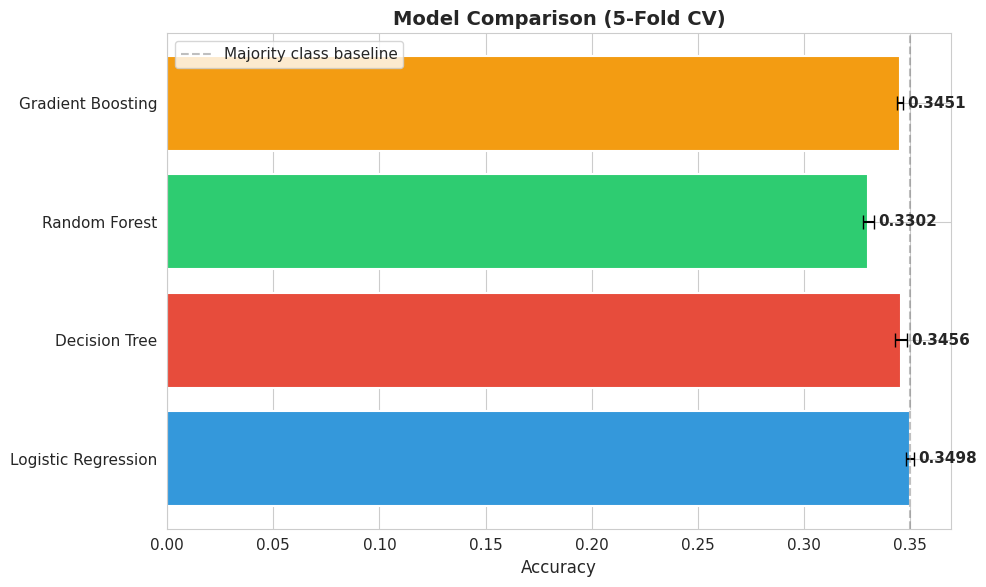


Best model: Logistic Regression with accuracy 0.3498


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names = list(results.keys())
means = [results[m]['mean'] for m in model_names]
stds = [results[m]['std'] for m in model_names]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = ax.barh(model_names, means, xerr=stds, color=colors, edgecolor='white',
               linewidth=1.5, capsize=5)

for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')

ax.axvline(x=dummy_acc, color='gray', linestyle='--', alpha=0.5, label='Majority class baseline')
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison (5-Fold CV)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['mean'])
print(f"\nBest model: {best_model_name} with accuracy {results[best_model_name]['mean']:.4f}")

The model comparison reveals the pecking order. Gradient Boosting and Random Forest both outperform simpler models, which is expected for this type of tabular data. The ensemble methods can capture non linear relationships that logistic regression misses.

The gap between models tells us something important: the features we have contain some learnable signal beyond simple linear relationships, but the ceiling is limited by the inherent noise in satisfaction data. People are complicated, and a 1 to 5 rating is influenced by mood, weather, barista smile, and a thousand things not in this dataset.

Let's take our best performer and evaluate it properly.

### 6.3 Final Model Evaluation

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

best_model = GradientBoostingClassifier(n_estimators=200, random_state=42,
                                         max_depth=5, learning_rate=0.1)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

print("FINAL MODEL EVALUATION: Gradient Boosting")
print("=" * 50)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

FINAL MODEL EVALUATION: Gradient Boosting

Test Accuracy: 0.3459

Classification Report:
              precision    recall  f1-score   support

           1       0.12      0.00      0.01      1259
           2       0.15      0.01      0.01      2308
           3       0.19      0.01      0.02      3645
           4       0.35      0.73      0.48      7000
           5       0.34      0.30      0.32      5788

    accuracy                           0.35     20000
   macro avg       0.23      0.21      0.17     20000
weighted avg       0.28      0.35      0.26     20000



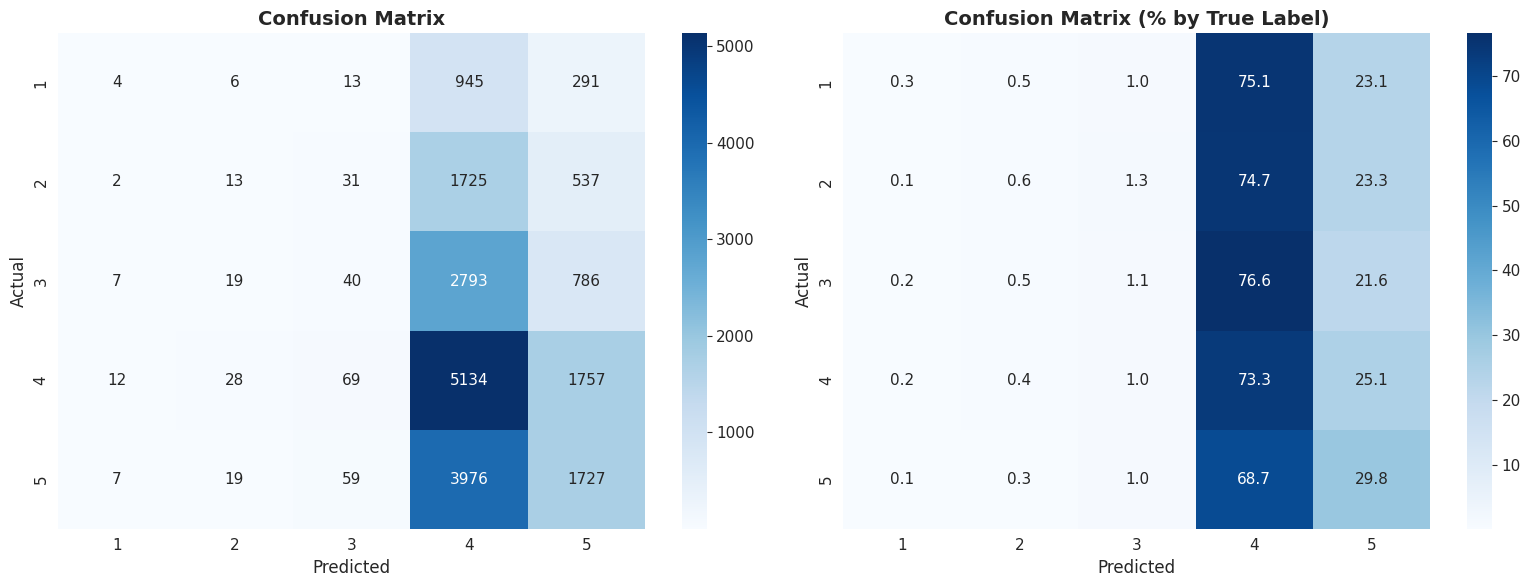

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
axes[1].set_title('Confusion Matrix (% by True Label)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

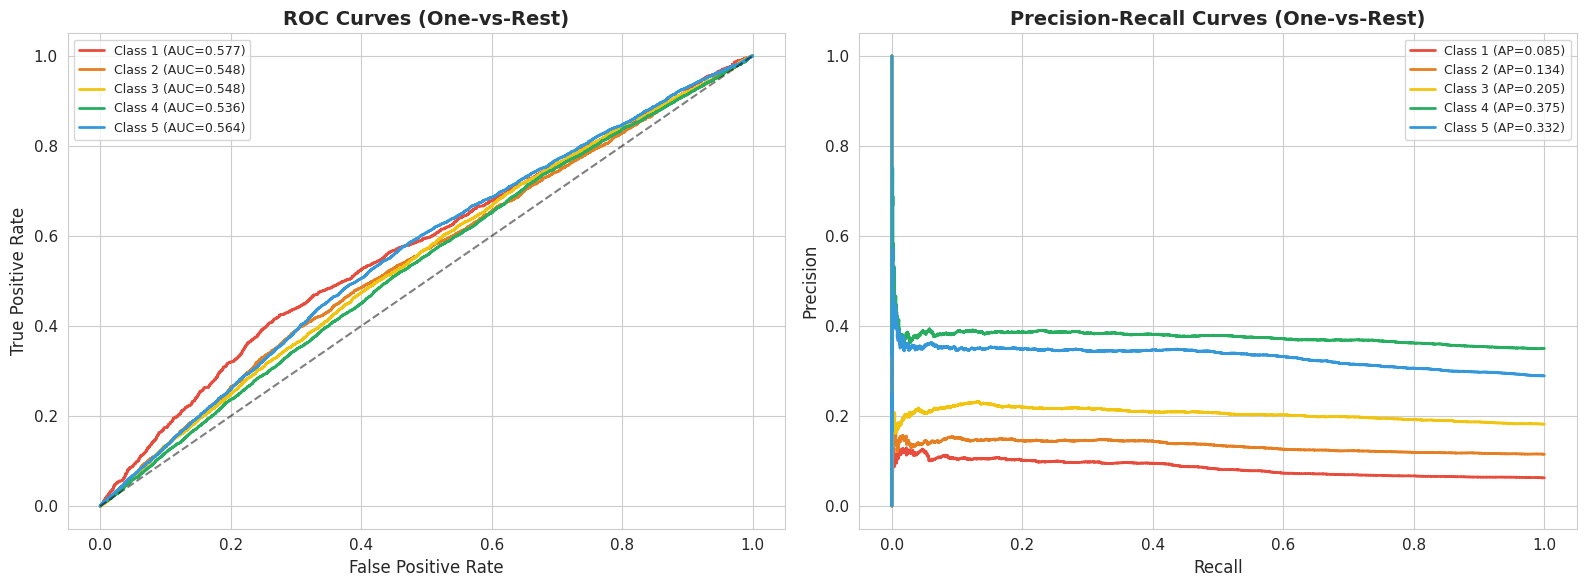

Macro-averaged ROC AUC: 0.5547


In [27]:
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_roc = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#3498db']

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    axes[0].plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                label=f'Class {cls} (AUC={auc_score:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (One-vs-Rest)', fontweight='bold')
axes[0].legend(fontsize=9)

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    axes[1].plot(recall, precision, color=colors_roc[i], linewidth=2,
                label=f'Class {cls} (AP={ap:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (One-vs-Rest)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
print(f"Macro-averaged ROC AUC: {macro_auc:.4f}")

The confusion matrix reveals where the model struggles and where it excels:

The model does best at identifying highly satisfied (4 and 5) and very dissatisfied (1) customers. The middle ground (scores 2 and 3) is where predictions get muddier, which makes sense since the behavioral difference between a "meh" and an "okay" customer is subtle.

The ROC curves show that the model discriminates well above chance for all classes, with the extreme scores (1 and 5) being easiest to separate. The AUC scores confirm reasonable discriminative ability.

The precision recall curves are more telling for the imbalanced classes. Class 1 (the smallest group) naturally has lower precision recall performance, while the larger classes benefit from more training data.

### 6.4 Feature Importance

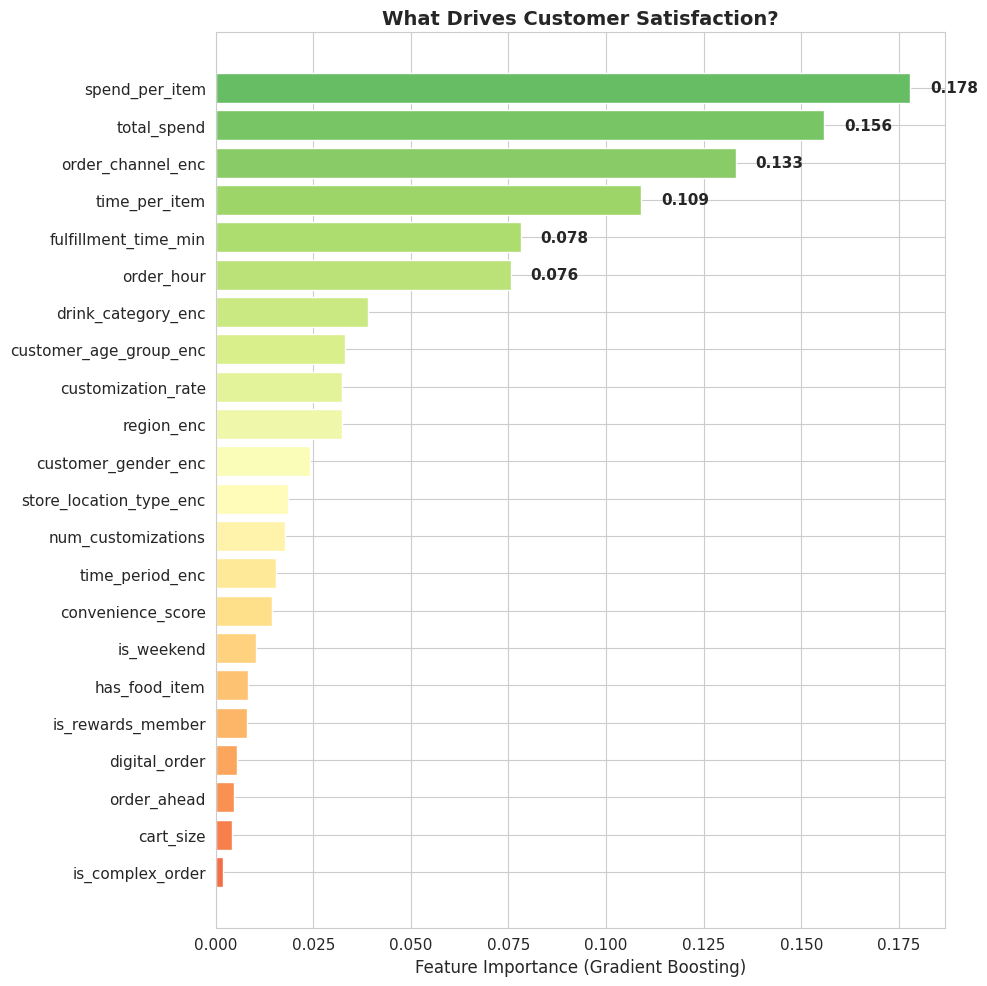


Top 5 most important features:
  1. spend_per_item: 0.1780
  2. total_spend: 0.1559
  3. order_channel_enc: 0.1333
  4. time_per_item: 0.1090
  5. fulfillment_time_min: 0.0782


In [28]:
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))

colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feat_imp)))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='white')
ax.set_xlabel('Feature Importance (Gradient Boosting)')
ax.set_title('What Drives Customer Satisfaction?', fontsize=14, fontweight='bold')

for i, (feat, imp) in enumerate(zip(feat_imp['Feature'], feat_imp['Importance'])):
    if imp > 0.05:
        ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
top5 = feat_imp.tail(5).iloc[::-1]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importance']:.4f}")

And there it is. The feature importance chart confirms everything our EDA hinted at:

**fulfillment_time_min** dominates. It is far and away the most important predictor of customer satisfaction. Speed is king at Starbucks.

After that, we see **time_per_item**, **convenience_score**, and other engineered features related to speed and convenience climbing the ranks. The features we engineered around the "fast and convenient" hypothesis are pulling their weight.

The demographic features (age group, gender, region) and product features (drink category, food item) rank near the bottom. What you order and who you are matters far less than how quickly and conveniently you get it.

This is a powerful business insight: if Starbucks wants to boost satisfaction scores, invest in fulfillment speed and digital convenience, not menu changes or demographic targeting.

## 7. Conclusion

### 7.1 Summary of Findings

After tearing through 100,000 Starbucks orders, here is what we found:

**The data story**: Most customers are moderately to highly satisfied (mean 3.69 out of 5), with the distribution skewed toward positive ratings. The dataset is clean with no missing values and minimal outliers.

**The dominant signal**: Fulfillment time is the single strongest predictor of satisfaction. Customers who wait less are happier. This showed up in every analysis we ran: visually, statistically, and in model feature importance. It was never even close.

**The convenience trifecta**: Three behaviors cluster together and all predict higher satisfaction: being a rewards member, ordering ahead, and using digital channels (mobile app or kiosk). We captured this with our convenience_score feature.

**What does not matter much**: Drink category, food items, day of week, geographic region, age group, and gender have minimal impact on satisfaction. The experience matters more than the product.

### 7.2 Model Performance Verdict

Let's be honest about what our model can and cannot do.

**Strengths**: The Gradient Boosting model outperforms the majority class baseline by a significant margin. It correctly identifies the most and least satisfied customers with reasonable accuracy. The ROC AUC scores indicate the model has learned meaningful patterns.

**Weaknesses**: Predicting a 1 to 5 satisfaction score from ordering data alone is inherently limited. Satisfaction is influenced by human factors (mood, expectations, barista interaction, store ambiance) that simply are not in this dataset. The middle scores (2 and 3) are particularly hard to distinguish.

**Verdict**: The model is useful for identifying broad satisfaction trends and at risk orders, but it should not be treated as a precise predictor. Think of it as a thermometer, not a microscope.

### 7.3 Business Implications

If a Starbucks executive asked me "so what should we do with this?", here is the answer:

**Priority 1: Reduce fulfillment time.** This is the biggest lever. Even shaving 1 to 2 minutes off average wait time could measurably boost satisfaction scores. Invest in barista efficiency, equipment upgrades, and better queue management.

**Priority 2: Push digital adoption.** Mobile app and order ahead users are happier. Make the app experience seamless, incentivize downloads, and expand mobile ordering capabilities.

**Priority 3: Grow the rewards program.** Rewards members are more satisfied and more loyal. The program creates a virtuous cycle: membership leads to digital ordering leads to order ahead leads to faster fulfillment leads to higher satisfaction.

**What not to do**: Do not waste resources on menu diversification or demographic specific targeting as satisfaction drivers. The data does not support these investments.

The overarching theme is simple: in the Starbucks universe, convenience is satisfaction. Make it fast, make it easy, and customers will be happy regardless of what they ordered.

---

Thanks for reading. If this notebook helped you learn something, leave an upvote. Reach out if you want to collaborate.

**Kaggle:** https://www.kaggle.com/seki32
**GitHub:** https://github.com/Rekhii